In [9]:
###############################################################################

In [1]:
# This cell is tagged for removal

import os
import pickle
from glob import glob

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

import aliases # important this goes first to configure PATH

from everest.window import Canvas, DataChannel as Channel
from everest.window.colourmaps import *
from everest.window import image, imop

from thesiscode.referencing import search
from thesiscode.general import *
from analysis import isovisc, arrhenius, utilities, common, analysis, visualisation

### Mixed heating in the annulus

#### Conductive solution

In [2]:
with open(os.path.join(aliases.storagedir, 'condhfmixed.pkl'), mode = 'rb') as file:
    conddata = pickle.loads(file.read())
condhs, condfs = zip(*conddata['hfs'])
condhs = tuple(round(val, 1) for val in condhs)
frm = pd.DataFrame(dict(H = condhs, f = condfs, T = conddata['avts'], geotherm = conddata['geotherms']))
frm = frm.set_index(['H', 'f'])
Hs, fs = (np.array(sorted(set(frm.index.get_level_values(level)))) for level in ('H', 'f'))

In [3]:
# impaths = sorted(
#     os.path.relpath(path)
#     for path in glob(
#         os.path.join(aliases.storagedir, 'cond_hf_mixed_*1-0.png')
#         )
#     )

array([ 0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  2. ,  4. ,  6. ,  8. , 10. ,
       12. ])

In [41]:
frm

,,T,geotherm
H,f,,
0.0,0.1,0.207140,"[1.0, 0.9429192280499759, 0.8924672727478444, ..."
0.2,0.1,0.225034,"[1.0, 0.9462214792712952, 0.8986422938983821, ..."
0.4,0.1,0.242928,"[1.0, 0.9495237293219909, 0.9048173129178653, ..."
0.6,0.1,0.260822,"[1.0, 0.952825978532684, 0.9109923304403201, 0..."
0.8,0.1,0.278716,"[1.0, 0.956128227177064, 0.9171673469935792, 0..."
...,...,...,...
4.0,1.0,0.833079,"[0.9999999999999577, 1.0151328373482005, 1.029..."
6.0,1.0,0.999705,"[0.9999999999999577, 1.0305161836048464, 1.059..."
8.0,1.0,1.166331,"[0.9999999999999577, 1.045898210221183, 1.0898..."


In [30]:
fs

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [19]:
frm.loc[0., 0.1]['geotherm']

(65,)

In [62]:
10 / 2

5.0

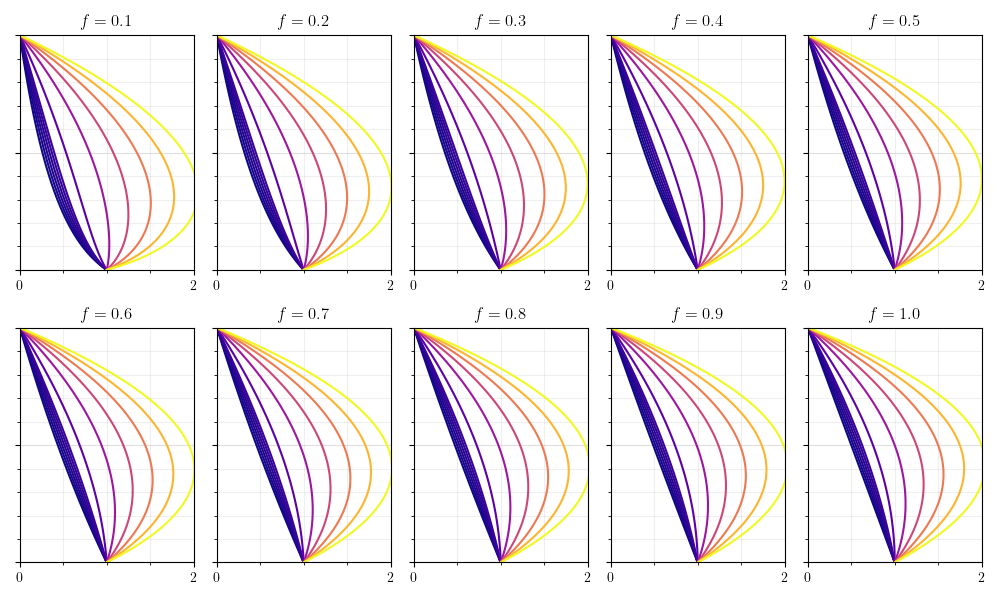

In [70]:
nfs = len(fs)
nrows = 2
ncols = round(nfs / nrows)
canvas = Canvas(shape=(nrows, ncols), size=(2*ncols, 3*nrows))
depths = np.linspace(0, 1, 65)
ychan = Channel(
    np.linspace(0, 1, 65), label='$h$',
    capped=(True, True),
    )
for index, f in enumerate(fs):
    ax = canvas.ax(
        (index // ncols, index % ncols),
        title=f'$f={f}$'
        )
    for H in Hs:
        ax.line(
            Channel(
                frm.loc[H, f]['geotherm'], label='$T$',
                lims=(0., 2.), capped=(True, True),
                ),
            ychan,
            c = cmap(H, condhs, style = 'plasma'),
            )
    ax.props.edges.x.label.visible = False
    ax.props.edges.y.label.visible = False
    ax.props.edges.y.ticks.major.labels = ()
canvas

In [59]:
5 % 5

0

In [56]:
6 // 5

1

In [48]:
ax.props.edges.y.label.

False

In [8]:
###############################################################################